In [2]:
import compresso, torch
import numpy as np
import pandas as pd

from __future__ import annotations

from abc import ABC, abstractmethod
from dataclasses import dataclass
from typing import Any, Dict, Iterable, Iterator, Mapping, Optional, Sequence, Union

import itertools
import multiprocessing.dummy
import queue
import random
import threading
import warnings
import weakref
import torch
import torch.nn as nn
from tqdm import tqdm
from contextlib import closing

import numpy as np

ArrayLike = Union[np.ndarray, Sequence[int], Sequence[str]]

# taken from keras https://github.com/keras-team/keras/blob/v3.3.3/keras/src/trainers/data_adapters/py_dataset_adapter.py#L18-L175

class PyDataset:
    """Base class for defining a parallel dataset using Python code.

    Every `PyDataset` must implement the `__getitem__()` and the `__len__()`
    methods. If you want to modify your dataset between epochs,
    you may additionally implement `on_epoch_end()`,
    or `on_epoch_begin` to be called at the start of each epoch.
    The `__getitem__()` method should return a complete batch
    (not a single sample), and the `__len__` method should return
    the number of batches in the dataset (rather than the number of samples).

    Args:
        workers: Number of workers to use in multithreading or
            multiprocessing.
        use_multiprocessing: Whether to use Python multiprocessing for
            parallelism. Setting this to `True` means that your
            dataset will be replicated in multiple forked processes.
            This is necessary to gain compute-level (rather than I/O level)
            benefits from parallelism. However it can only be set to
            `True` if your dataset can be safely pickled.
        max_queue_size: Maximum number of batches to keep in the queue
            when iterating over the dataset in a multithreaded or
            multiprocessed setting.
            Reduce this value to reduce the CPU memory consumption of
            your dataset. Defaults to 10.

    Notes:

    - `PyDataset` is a safer way to do multiprocessing.
        This structure guarantees that the model will only train
        once on each sample per epoch, which is not the case
        with Python generators.
    - The arguments `workers`, `use_multiprocessing`, and `max_queue_size`
        exist to configure how `fit()` uses parallelism to iterate
        over the dataset. They are not being used by the `PyDataset` class
        directly. When you are manually iterating over a `PyDataset`,
        no parallelism is applied.

    Example:

    ```python
    from skimage.io import imread
    from skimage.transform import resize
    import numpy as np
    import math

    # Here, `x_set` is list of path to the images
    # and `y_set` are the associated classes.

    class CIFAR10PyDataset(keras.utils.PyDataset):

        def __init__(self, x_set, y_set, batch_size, **kwargs):
            super().__init__(**kwargs)
            self.x, self.y = x_set, y_set
            self.batch_size = batch_size

        def __len__(self):
            # Return number of batches.
            return math.ceil(len(self.x) / self.batch_size)

        def __getitem__(self, idx):
            # Return x, y for batch idx.
            low = idx * self.batch_size
            # Cap upper bound at array length; the last batch may be smaller
            # if the total number of items is not a multiple of batch size.
            high = min(low + self.batch_size, len(self.x))
            batch_x = self.x[low:high]
            batch_y = self.y[low:high]

            return np.array([
                resize(imread(file_name), (200, 200))
                   for file_name in batch_x]), np.array(batch_y)
    ```
    """

    def __init__(self, workers=1, use_multiprocessing=False, max_queue_size=10):
        self._workers = workers
        self._use_multiprocessing = use_multiprocessing
        self._max_queue_size = max_queue_size

    def _warn_if_super_not_called(self):
        warn = False
        if not hasattr(self, "_workers"):
            self._workers = 1
            warn = True
        if not hasattr(self, "_use_multiprocessing"):
            self._use_multiprocessing = False
            warn = True
        if not hasattr(self, "_max_queue_size"):
            self._max_queue_size = 10
            warn = True
        if warn:
            warnings.warn(
                "Your `PyDataset` class should call "
                "`super().__init__(**kwargs)` in its constructor. "
                "`**kwargs` can include `workers`, "
                "`use_multiprocessing`, `max_queue_size`. Do not pass "
                "these arguments to `fit()`, as they will be ignored.",
                stacklevel=2,
            )

    @property
    def workers(self):
        self._warn_if_super_not_called()
        return self._workers

    @workers.setter
    def workers(self, value):
        self._workers = value

    @property
    def use_multiprocessing(self):
        self._warn_if_super_not_called()
        return self._use_multiprocessing

    @use_multiprocessing.setter
    def use_multiprocessing(self, value):
        self._use_multiprocessing = value

    @property
    def max_queue_size(self):
        self._warn_if_super_not_called()
        return self._max_queue_size

    @max_queue_size.setter
    def max_queue_size(self, value):
        self._max_queue_size = value

    def __getitem__(self, index):
        """Gets batch at position `index`.

        Args:
            index: position of the batch in the PyDataset.

        Returns:
            A batch
        """
        del index
        raise NotImplementedError

    def __iter__(self):
        index_range = None
        try:
            num_batches = self.num_batches
            if num_batches is not None:
                index_range = range(num_batches)
        except NotImplementedError:
            pass

        if index_range is None:
            index_range = itertools.count()

        for index in index_range:
            yield self[index]

    @property
    def num_batches(self):
        """Number of batches in the PyDataset.

        Returns:
            The number of batches in the PyDataset or `None` to indicate that
            the dataset is infinite.
        """
        # For backwards compatibility, support `__len__`.
        if hasattr(self, "__len__"):
            return len(self)
        raise NotImplementedError(
            "You need to implement the `num_batches` property:\n\n"
            "@property\ndef num_batches(self):\n  return ..."
        )

    def on_epoch_begin(self):
        """Method called at the beginning of every epoch."""
        pass

    def on_epoch_end(self):
        """Method called at the end of every epoch."""
        pass





class TorchModel(nn.Module, ABC):
    def __init__(self) -> None:
        super().__init__()
        self.optimizer: Optional[torch.optim.Optimizer] = None
        self.scheduler: Optional[Any] = None
        self._compiled: bool = False

    def _compile(
        self,
        *,
        optimizer: torch.optim.Optimizer,
        scheduler: Optional[Any] = None,
        device: Optional[str | torch.device] = None,
    ) -> None:
        self.optimizer = optimizer
        self.scheduler = scheduler

        if device is not None:
            self.to(device)

        self._compiled = True

    def _ensure_compiled(self) -> None:
        if not self._compiled or self.optimizer is None:
            raise RuntimeError("Model is not compiled. Call .compile(...) first.")

    @abstractmethod
    def forward(self, batch: Dict[str, Any]) -> Any:
        raise NotImplementedError

    @abstractmethod
    def compute_loss(self, batch: Dict[str, Any], outputs: Any) -> torch.Tensor:
        raise NotImplementedError

    def compute_metrics(self, batch: Dict[str, Any], outputs: Any) -> Dict[str, float]:
        return {}

    def train_step(self, batch: Dict[str, Any]) -> Dict[str, float]:
        self._ensure_compiled()
        assert self.optimizer is not None

        self.train()
        self.optimizer.zero_grad(set_to_none=True)

        outputs = self.forward(batch)
        loss = self.compute_loss(batch, outputs)
        loss.backward()
        self.optimizer.step()

        if self.scheduler is not None:
            self.scheduler.step()

        logs = {"loss": float(loss.detach().cpu())}
        logs.update(self.compute_metrics(batch, outputs))
        return logs

    @torch.no_grad()
    def eval_step(self, batch: Dict[str, Any]) -> Dict[str, float]:
        self.eval()

        outputs = self.forward(batch)
        loss = self.compute_loss(batch, outputs)

        logs = {"loss": float(loss.detach().cpu())}
        logs.update(self.compute_metrics(batch, outputs))
        return logs

    @torch.no_grad()
    def predict_step(self, batch: Dict[str, Any]) -> Any:
        self.eval()
        return self.forward(batch)

    def fit(
        self,
        train_loader: Iterable[Dict[str, Any]],
        *,
        epochs: int = 1,
        val_loader: Optional[Iterable[Dict[str, Any]]] = None,
        verbose: bool = True,
    ) -> Dict[str, list[Dict[str, float]]]:
        self._ensure_compiled()

        history = {"train": [], "val": []}

        for epoch in range(1, epochs + 1):
            train_sum: Dict[str, float] = {}
            train_steps = 0

            iterator = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", mininterval=1) if verbose else train_loader

            for batch in iterator:
                logs = self.train_step(batch)
                train_steps += 1

                for k, v in logs.items():
                    train_sum[k] = train_sum.get(k, 0.0) + float(v)

                avg_logs = {k: v / train_steps for k, v in train_sum.items()}
                if verbose and hasattr(iterator, "set_postfix"):
                    iterator.set_postfix({k: f"{v:.4f}" for k, v in avg_logs.items()})

            train_epoch_logs = {k: v / train_steps for k, v in train_sum.items()}
            history["train"].append(train_epoch_logs)

            if val_loader is not None:
                val_logs = self.evaluate(val_loader, verbose=verbose)
                history["val"].append(val_logs)

        return history

    @torch.no_grad()
    def evaluate(
        self,
        loader: Iterable[Dict[str, Any]],
        *,
        verbose: bool = False,
    ) -> Dict[str, float]:
        self._ensure_compiled()

        val_sum: Dict[str, float] = {}
        val_steps = 0

        iterator = tqdm(loader, desc="Evaluating", mininterval=1) if verbose else loader

        for batch in iterator:
            logs = self.eval_step(batch)
            val_steps += 1

            for k, v in logs.items():
                val_sum[k] = val_sum.get(k, 0.0) + float(v)

        return {k: v / val_steps for k, v in val_sum.items()}

    @torch.no_grad()
    def predict(self, loader: Iterable[Dict[str, Any]]) -> list[Any]:
        self._ensure_compiled()
        return [self.predict_step(batch) for batch in loader]

In [3]:
import math

class MnistDataset(PyDataset):
        def __init__(self, x_set, y_set, batch_size, shuffle=True,seed=42,device="cpu",**kwargs):
            super().__init__(**kwargs)
            self.x, self.y = x_set, y_set
            self.batch_size = batch_size
            self.shuffle = shuffle
            self._rng = np.random.default_rng(seed)
            self.indices = np.arange(self.x.shape[0])
            self.device = device
            if self.shuffle:
                self._rng.shuffle(self.indices)
            
        def __len__(self):
            # Return number of batches.
            return math.ceil(len(self.x) / self.batch_size)

        def __getitem__(self, idx):
            # Return x, y for batch idx.
            low = idx * self.batch_size
            # Cap upper bound at array length; the last batch may be smaller
            # if the total number of items is not a multiple of batch size.
            high = min(low + self.batch_size, len(self.x))
            batch_x = self.x[low:high]
            batch_y = self.y[low:high]

            return {
                "x": torch.flatten(self.x[self.indices[low:high]]/255, start_dim=1).to(self.device), 
                "y": self.y[self.indices[low:high]].to(self.device),
            }

        def on_epoch_end(self) -> None:
            if self.shuffle:
                self._rng.shuffle(self.indices)
            

In [54]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import compresso

class Normalize(nn.Module):
    def __init__(self, p=2.0, dim=1, eps=1e-12, out=None):
        super().__init__()
        self.p = p
        self.dim = dim
        self.eps = eps
        self.out = out
        
    def forward(self, x):
        return torch.nn.functional.normalize(x, self.p, self.dim, self.eps, self.out)

class MNISTClassifier(TorchModel):
    def __init__(self, sparse_dim, k_classify=1, k_reconstruct=5) -> None:
        super().__init__()
        self.hidden_dim=sparse_dim
        self.k_classify=k_classify
        self.k_reconstruct=k_reconstruct
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, self.hidden_dim),
            #Normalize(dim=-1, p=1.),
        )
        self.sparse_class = nn.Sequential(
            #nn.ReLU(),
            compresso.nn.TopKSparsify(self.k_classify, k_backward=self.k_classify),
            #Normalize(dim=-1, p=10.),
        )
        self.sparse_reconstruct_ = nn.Sequential(
            #nn.ReLU(),
            compresso.nn.TopKSparsify(self.k_reconstruct, k_backward=self.k_reconstruct),
            #Normalize(dim=-1, p=10.),
            #nn.Tanh(reduction="mean")
        )
        self.sparse_reconstruct = self.sparse_class
        self.classifier = nn.Sequential(
            nn.Linear(self.hidden_dim, 10),
        )
        self.decoder = nn.Sequential(
            nn.Linear(self.hidden_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            #nn.ReLU(),
            #nn.Softmax(dim=-1),
            nn.Unflatten(1, (28,28)),
        )
        self.simple_decoder = nn.Sequential(
            nn.Linear(self.hidden_dim, 28 * 28),
            nn.Unflatten(1, (28,28)),
        )
        
    def forward(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        x = batch["x"]
        latent = self.encoder(x)
        sparse_class = self.sparse_class(latent)
        sparse_reconstruct = self.sparse_reconstruct(latent)
        
        logits = self.classifier(sparse_class)
        reconstruct = self.decoder(sparse_reconstruct)
        return logits, reconstruct

    def compute_loss(self, batch: Dict[str, torch.Tensor], outputs: torch.Tensor) -> torch.Tensor:
        logits, reconstruct = outputs
        y = batch["y"]
        x = batch["x"]
        loss_classify = F.cross_entropy(logits, y)
        #loss_reconstruct = F.binary_cross_entropy_with_logits(reconstruct.flatten(start_dim=1), x)
        loss_reconstruct = F.mse_loss(reconstruct.flatten(start_dim=1), x)
        #loss_reconstruct = F.huber_loss(reconstruct.flatten(start_dim=1), x)
        return .0*loss_classify+loss_reconstruct

    def compute_metrics(self, batch: Dict[str, torch.Tensor], outputs: torch.Tensor) -> Dict[str, float]:
        y = batch["y"]
        x = batch["x"]
        logits, reconstruct = outputs
        pred = logits.argmax(dim=1)
        acc = (pred == y).float().mean()
        mse = F.mse_loss(reconstruct.flatten(start_dim=1), x, reduce="mean")
        return {"accuracy": float(acc.detach().cpu()), "mse": float(mse.detach().cpu())}

In [55]:
import torch
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()

train_ds = datasets.MNIST(root="mnist-data", train=True, download=True, transform=transform)
val_ds = datasets.MNIST(root="mnist-data", train=False, download=True, transform=transform)

train_loader = MnistDataset(train_ds.data,train_ds.targets, 256,device = "cuda") #make_loader(train_ds, batch_size=256, shuffle=True)
val_loader = MnistDataset(val_ds.data,val_ds.targets, 512,device = "cuda") #make_loader(val_ds, batch_size=512, shuffle=False)
model = MNISTClassifier(16,4,4)
#model.encoder[6].k_backward = model.encoder[6].k
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-1)

model._compile(
    optimizer=optimizer,
    device=device,
)

model.cuda()

history = model.fit(
    train_loader,
    val_loader=val_loader,
    epochs=20,
    verbose=True,
)

print("train",history["train"][-1])
print("val",history["val"][-1])

Epoch 1/20:   0%|          | 0/235 [00:00<?, ?it/s]/home/vojta/keras3/lib/python3.10/site-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='mean' instead.
  warnings.warn(warning.format(ret))
Evaluating: 100%|██████████| 20/20 [00:00<00:00, 772.52it/s]

train {'loss': 0.02637845536178731, 'accuracy': 0.18527814720539337, 'mse': 0.02637845536178731}
val {'loss': 0.02660606037825346, 'accuracy': 0.19601332694292067, 'mse': 0.02660606037825346}


In [15]:
history = model.fit(
    train_loader,
    val_loader=val_loader,
    epochs=20,
    verbose=True,
)

print("train",history["train"][-1])
print("val",history["val"][-1])

Evaluating: 100%|██████████| 20/20 [00:00<00:00, 685.78it/s]

train {'loss': 0.025733217842718387, 'accuracy': 0.107485594013904, 'mse': 0.025733217842718387}
val {'loss': 0.026082684751600027, 'accuracy': 0.12058249115943909, 'mse': 0.026082684751600027}


<Axes: >

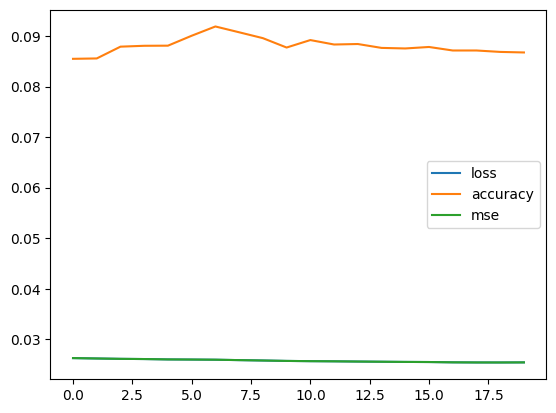

In [7]:
pd.DataFrame(history["val"]).plot()

In [80]:
import PIL
from IPython.display import display
samples=range(100)
j=1
d = val_loader[j]
_pic, label = d["x"], d["y"]
for i in samples:
    pic = _pic[i]
    tens = pic
    if label[i]==5:
        print(i)
        display(PIL.Image.fromarray((pic.reshape([28,28]).cpu().numpy()*255).astype("uint8")))
        rep1=model.sparse_class(model.encoder(tens[None, :]))
        #print(torch.where(rep1!=0)[1])
        #print(rep1[torch.where(rep1!=0)])
        rep=model.sparse_reconstruct(model.encoder(tens[None, :]))
        #print(torch.where(rep!=0)[1])
        #print(rep[torch.where(rep!=0)])
        logits, reconstruct = model({"x":tens[None, :]})
        #print(torch.argmax(logits))
        display(PIL.Image.fromarray((reconstruct[0].detach().cpu().numpy()*255).clip(0,255).astype("uint8")))

14


26


28


33


42


45


49


63


65


82


88


In [942]:
synthetic=torch.from_numpy(np.array([[
    0, 0.0, 1, 0, 0, 
    0, 0., 0, 0, 0.0, #7
    0, 0., 0, -0, -0., 
    0, 
]]
)).float()
display(PIL.Image.fromarray((model.decoder(synthetic.cuda())[0].detach().cpu().numpy()*255).clip(0,255).astype("uint8")))

In [943]:
synthetic=torch.from_numpy(np.array([[
    -0., 0, 0, 0, 0, 
    0, 0., 0, -1, 0., #7
    0, -0., -0, -0, 0, 
    0, 
]]
)).float()
display(PIL.Image.fromarray((model.decoder(synthetic.cuda())[0].detach().cpu().numpy()*255).clip(0,255).astype("uint8")))

In [861]:
synthetic=torch.from_numpy(np.array([[
    0, 0, 0, 0, 0, 
    0, -0.0, 0.0, 0, 1, #7
    0, -0., 0, -0, 0, 
    0, 
]]
)).float()
display(PIL.Image.fromarray((model.decoder(synthetic.cuda())[0].detach().cpu().numpy()*255).clip(0,255).astype("uint8")))

In [869]:
synthetic=torch.from_numpy(np.array([[
    -0, 0, 0, 0, 0, 
    0, -0.0, 0.0, 0, 0, #7
    1, -0., -0., -0, 0, 
    0, 
]]
)).float()
display(PIL.Image.fromarray((model.decoder(synthetic.cuda())[0].detach().cpu().numpy()*255).clip(0,255).astype("uint8")))

In [871]:
synthetic=torch.from_numpy(np.array([[
    -0, 0, 0, 0, 0, 
    0, -0.0, 0.0, 0, 0.3, #7
    0.3, -0., -0.3, -0, 0, 
    0, 
]]
)).float()
display(PIL.Image.fromarray((model.decoder(synthetic.cuda())[0].detach().cpu().numpy()*255).clip(0,255).astype("uint8")))

In [729]:
synthetic=torch.from_numpy(np.array([[
    0, 0, 0., 0, 0, 
    0, 0, 0, 0, 0, #7
    0, 0., 0, 0., 0, 
    -1, 0, 0, 0, 0,
    0, 0, 0, 0, 0,
    0, 0, 0, -0, 0, #26, 28
    0., -0.0,
]]
)).float()
display(PIL.Image.fromarray((model.decoder(synthetic.cuda())[0].detach().cpu().numpy()*255).clip(0,255).astype("uint8")))

In [628]:
synthetic=torch.from_numpy(np.array([[
    0, 0, 0, 2, 0, 
    0, 0, 0, 0, 0, #7
    0, 0., 0, 0, 0, 
    0, 0, 0, 0, 0,
    0., -0., 0., 0, 0.,
    0, 0, 0, 0, 0, #26, 28
    0, 0,
]]
)).float()
display(PIL.Image.fromarray((model.decoder(synthetic.cuda())[0].detach().cpu().numpy()*255).clip(0,255).astype("uint8")))

In [657]:
synthetic=torch.from_numpy(np.array([[
    0, -2, 0, 0, 0, 
    0, 0, 0, 0, 0, #7
    0, 0., 0, 0, 0, 
    0, 0, 0, 0, 0,
    0., -0., 0., 0, 0.,
    0, 0, 0, .1, 0, #26, 28
    0, 0,
]]
)).float()
display(PIL.Image.fromarray((model.decoder(synthetic.cuda())[0].detach().cpu().numpy()*255).clip(0,255).astype("uint8")))

In [73]:
dfs = []
for batch in val_loader:
    rep=model.sparse_reconstruct(model.encoder(batch["x"]))
    
    e_topk=torch.topk(torch.abs(rep), 1, -1)
    mvals=torch.zeros_like(rep).scatter(-1, e_topk.indices, e_topk.values) * torch.sign(rep)
    
    df=pd.DataFrame(
        {
            "values":list(rep[torch.where(mvals!=0)].cpu().detach().numpy()),
            "label":list(batch["y"].cpu().numpy()),
            "concept":list(1+e_topk.indices.flatten().cpu().detach().numpy()),
        }
    )
    dfs.append(df)
df = pd.concat(dfs)
df["concept"]=df.concept*np.sign(df["values"].to_numpy())

In [75]:
from collections import Counter
label_map = {}
for l in np.sort(df.label.unique()):
    dd=dict(Counter(df[df.label==l].concept))
    concept=list(dd.keys())[np.argmax(list(dd.values()))]
    label_map[l]=concept

for label, concept in label_map.items():  
    print(f"label: {label}, concept: {concept} (latent factor #{int(abs(concept))} is set to {np.sign(concept)})")
    a = np.zeros(16)
    a[int(np.abs(concept))-1]=np.sign(concept)
    a = a[None, :]
    synthetic=torch.from_numpy(a).float()*10
    display(PIL.Image.fromarray((model.decoder(synthetic.cuda())[0].detach().cpu().numpy()*255).clip(0,255).astype("uint8")))

label: 0, concept: 5.0 (latent factor #5 is set to 1.0)


label: 1, concept: -7.0 (latent factor #7 is set to -1.0)


label: 2, concept: 1.0 (latent factor #1 is set to 1.0)


label: 3, concept: 5.0 (latent factor #5 is set to 1.0)


label: 4, concept: 7.0 (latent factor #7 is set to 1.0)


label: 5, concept: 5.0 (latent factor #5 is set to 1.0)


label: 6, concept: 10.0 (latent factor #10 is set to 1.0)


label: 7, concept: -10.0 (latent factor #10 is set to -1.0)


label: 8, concept: 4.0 (latent factor #4 is set to 1.0)


label: 9, concept: -13.0 (latent factor #13 is set to -1.0)


Label 0


<Axes: ylabel='Frequency'>

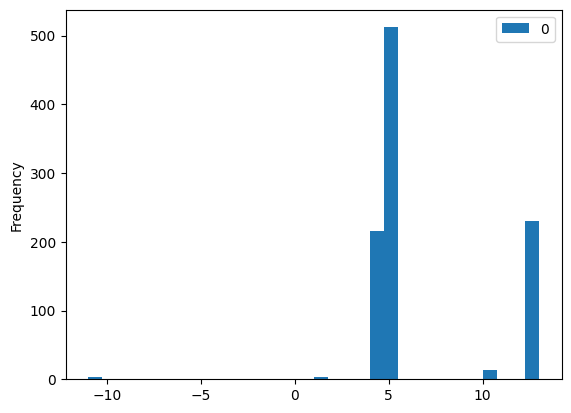

In [81]:
print("Label 0")
display(df[df.label==0].concept.plot(kind="hist",label="0", legend=True,bins=32))


Label 3


<Axes: ylabel='Frequency'>

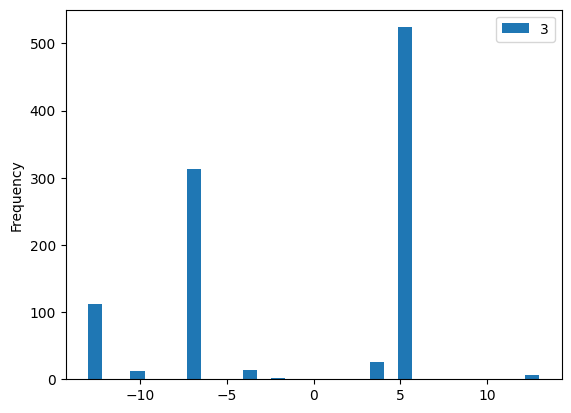

In [83]:
print("Label 3")
display(df[df.label==3].concept.plot(kind="hist",label="3", legend=True,bins=32))

Label 5


<Axes: ylabel='Frequency'>

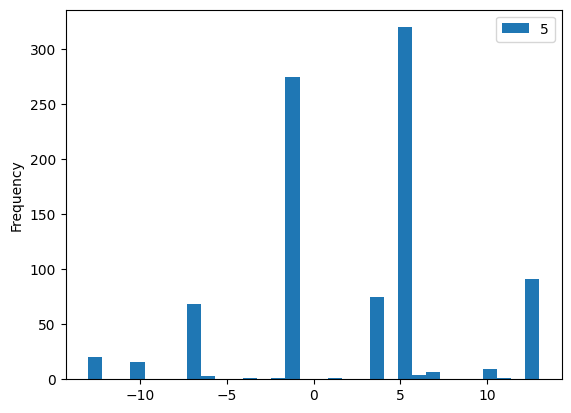

In [84]:
print("Label 5")
display(df[df.label==5].concept.plot(kind="hist",label="5", legend=True,bins=32))

In [1028]:
dict(Counter(df[df.label==0].concept)).values()

dict_values([1, 971, 2, 3, 1, 1, 1])

In [944]:
batch = val_loader[0]
batch

{'x': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0'),
 'y': tensor([5, 1, 4, 6, 9, 0, 8, 4, 7, 0, 4, 9, 7, 1, 3, 2, 2, 2, 6, 1, 9, 3, 2, 0,
         6, 6, 3, 7, 4, 8, 7, 8, 5, 6, 4, 9, 2, 8, 6, 3, 6, 9, 7, 9, 7, 1, 7, 9,
         5, 1, 5, 0, 9, 6, 5, 0, 6, 6, 1, 3, 9, 1, 1, 7, 9, 5, 0, 3, 5, 9, 6, 4,
         2, 1, 9, 8, 9, 6, 6, 4, 5, 0, 6, 5, 0, 0, 3, 3, 6, 5, 9, 8, 1, 8, 8, 3,
         5, 5, 2, 1, 3, 4, 8, 7, 3, 9, 1, 4, 5, 5, 4, 4, 6, 7, 7, 6, 5, 9, 7, 1,
         0, 6, 7, 1, 4, 4, 7, 5, 5, 1, 7, 5, 4, 0, 8, 9, 7, 8, 6, 1, 7, 8, 1, 0,
         2, 2, 1, 5, 8, 1, 6, 4, 0, 6, 5, 5, 5, 5, 5, 8, 1, 0, 3, 8, 9, 6, 7, 9,
         7, 1, 0, 1, 7, 0, 7, 7, 7, 1, 8, 4, 0, 5, 9, 7, 5, 4, 2, 3, 7, 7, 6, 1,
         8, 9, 6, 9, 2, 6, 8, 1, 7, 0, 0, 4, 2, 1, 1, 2, 8, 1, 

In [946]:
rep=model.sparse_reconstruct(model.encoder(batch["x"]))

<Axes: ylabel='Frequency'>

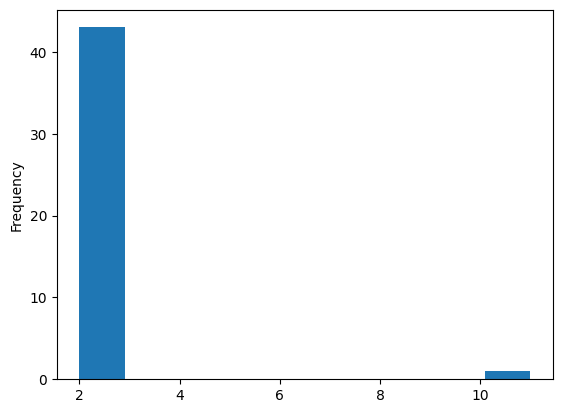

In [994]:
e_topk=torch.topk(torch.abs(rep), 1, -1)
mvals=torch.zeros_like(rep).scatter(-1, e_topk.indices, e_topk.values) * torch.sign(rep)

df=pd.DataFrame(
    {
        "values":list(rep[torch.where(mvals!=0)].cpu().detach().numpy()),
        "label":list(batch["y"].cpu().numpy()),
        "concept":list(e_topk.indices.flatten().cpu().detach().numpy()),
    }
)
df[df.label==4].concept.plot(kind="hist")

In [993]:
synthetic=torch.from_numpy(np.array([[
    -0, 0, 1, 0, 0, 
    0, -0.0, 0.0, 0, 0, #7
    0, -0., -0., -0, 0, 
    0, 
]]
)).float()
display(PIL.Image.fromarray((model.decoder(synthetic.cuda())[0].detach().cpu().numpy()*255).clip(0,255).astype("uint8")))

In [952]:
torch.sign(rep.()[torch.argmax(rep.abs(), dim=-1)])

tensor([[0., 0., 1.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 1.],
        [0., 0., 1.,  ..., 0., 1., 0.],
        ...,
        [0., 0., 1.,  ..., 1., 0., 0.],
        [0., 0., 1.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 1.]], device='cuda:0',
       grad_fn=<SignBackward0>)

In [440]:
import PIL
from IPython.display import display
samples=range(100)
j=1
d = val_loader[j]
_pic, label = d["x"], d["y"]
for i in samples:
    pic = _pic[i]
    tens = pic
    if label[i]==0:
        rep=model.encoder(tens[None, :])
        print(i)
        display(PIL.Image.fromarray((pic.reshape([28,28]).cpu().numpy()*255).astype("uint8")))
        print(torch.where(rep!=0)[1])
        print(rep[torch.where(rep!=0)])
        logits, reconstruct = model({"x":tens[None, :]})
        print(torch.argmax(logits))
        display(PIL.Image.fromarray((reconstruct[0].detach().cpu().numpy()*255).clip(0,255).astype("uint8")))

13


tensor([  0,   3,   9,  18,  50,  52,  61, 103], device='cuda:0')
tensor([ 0.4112, -0.2721,  0.2596, -0.2848,  0.3410, -0.3744,  0.2775,  0.5243],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(5, device='cuda:0')


18


tensor([ 12,  18,  26,  55,  64,  74,  88, 113], device='cuda:0')
tensor([ 0.2924, -0.2396,  0.2519,  0.5964,  0.4428, -0.2533,  0.2093,  0.3659],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


25


tensor([  0,  16,  18,  26,  35,  38,  99, 112], device='cuda:0')
tensor([ 0.4554,  0.2184, -0.4515,  0.3239, -0.2283, -0.3565,  0.4337, -0.2623],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


32


tensor([  3,  25,  39,  50,  56,  61, 103, 109], device='cuda:0')
tensor([-0.3335,  0.4177, -0.3930,  0.3373,  0.3363,  0.2782,  0.3258,  0.3867],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(4, device='cuda:0')


52


tensor([  0,  15,  18,  35,  57,  98,  99, 112], device='cuda:0')
tensor([ 0.4864, -0.2218, -0.2891, -0.5675, -0.2010, -0.2002,  0.3631, -0.3101],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


64


tensor([ 0, 18, 38, 40, 46, 52, 91, 99], device='cuda:0')
tensor([ 0.2865, -0.3124, -0.3693, -0.2760, -0.2378, -0.4889,  0.2570,  0.4960],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


74


tensor([  0,   3,  18,  26,  50,  64,  99, 112], device='cuda:0')
tensor([ 0.5016, -0.2775, -0.3694,  0.2075,  0.2645,  0.2628,  0.4654, -0.3692],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(8, device='cuda:0')


78


tensor([ 0, 10, 11, 26, 35, 38, 52, 88], device='cuda:0')
tensor([ 0.6164,  0.2014,  0.2775,  0.3064, -0.3718, -0.1869, -0.4487, -0.1845],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


87


tensor([  9,  15,  17,  22,  25,  35,  39, 116], device='cuda:0')
tensor([ 0.2768,  0.2276, -0.3646,  0.5171,  0.4915,  0.2069, -0.3727,  0.2189],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(1, device='cuda:0')


In [437]:
import PIL
from IPython.display import display
samples=range(100)
j=1
d = val_loader[j]
_pic, label = d["x"], d["y"]
for i in samples:
    pic = _pic[i]
    tens = pic
    if label[i]==0:
        rep=model.encoder(tens[None, :])
        print(i)
        display(PIL.Image.fromarray((pic.reshape([28,28]).cpu().numpy()*255).astype("uint8")))
        print(torch.where(rep!=0)[1])
        print(rep[torch.where(rep!=0)])
        logits, reconstruct = model({"x":tens[None, :]})
        print(torch.argmax(logits))
        display(PIL.Image.fromarray((reconstruct[0].detach().cpu().numpy()*255).clip(0,255).astype("uint8")))

13


tensor([  2,  28,  39,  68,  83,  93,  94, 105], device='cuda:0')
tensor([ 0.4168,  0.2989, -0.2715, -0.2823,  0.3589, -0.3587,  0.3763, -0.4295],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


18


tensor([  2,  28,  39,  68,  83,  93,  94, 105], device='cuda:0')
tensor([ 0.3981,  0.2944, -0.3518, -0.3503,  0.3724, -0.3166,  0.2987, -0.4246],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


25


tensor([  2,  28,  39,  68,  83,  93,  94, 105], device='cuda:0')
tensor([ 0.4381,  0.2513, -0.2888, -0.3574,  0.3193, -0.3319,  0.3869, -0.4147],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


32


tensor([  2,  28,  39,  68,  83,  93,  94, 105], device='cuda:0')
tensor([ 0.3441,  0.3139, -0.3427, -0.3403,  0.3103, -0.4064,  0.3474, -0.4095],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


52


tensor([  2,  28,  39,  68,  83,  93,  94, 105], device='cuda:0')
tensor([ 0.4510,  0.2717, -0.2739, -0.3563,  0.2962, -0.3300,  0.3951, -0.4099],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


64


tensor([  2,  28,  39,  68,  83,  93,  94, 105], device='cuda:0')
tensor([ 0.4255,  0.2656, -0.2748, -0.3311,  0.3237, -0.3359,  0.4005, -0.4304],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


74


tensor([  2,  28,  39,  68,  83,  93,  94, 105], device='cuda:0')
tensor([ 0.4379,  0.2732, -0.2713, -0.3326,  0.3296, -0.3290,  0.3927, -0.4223],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


78


tensor([  2,  28,  39,  68,  83,  93,  94, 105], device='cuda:0')
tensor([ 0.4526,  0.2912, -0.2613, -0.3118,  0.3151, -0.3261,  0.3734, -0.4470],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


87


tensor([  2,  28,  39,  68,  83,  93,  94, 105], device='cuda:0')
tensor([ 0.3389,  0.2862, -0.3485, -0.3228,  0.3089, -0.4298,  0.3585, -0.4110],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


In [405]:

(reconstruct[0].detach().cpu().numpy()*255).astype("uint8")

array([[  0,   0,   0,   0, 253, 255, 253,   0,   0,   2,   0,   2,   1,
          2, 255,   2, 253,   0,   0,   0,   0,   0, 255,   0,   1,   2,
          1,   0],
       [  1,   0,   0, 255, 254,   0,   1, 255,   0,   1,   0,   0,   3,
          0,   5,   1,   3,   1, 254,   1,   1,   1,   0, 255,   1,   0,
          2, 254],
       [  0, 255,   0,   1, 255,   0,   1,   1,   0,   5,   3,   4,   2,
          4,   5,  12,  18,  22,  19,  16,   5,   5,   4,   3,   1,   1,
        255,   0],
       [  0,   1, 255, 255,   0,   1,   0,   0,   1, 255,   9,   3,   9,
          4,  16,  29,  42,  52,  55,  40,  20,  13,   6,   2,   1,   0,
          0,   0],
       [  0, 255,   0,   2,   2,   2, 255, 255,   3,   6,   4,   9,   7,
         17,  33,  45,  55,  56,  46,  29,  16,  11,   3,   0,   3,   1,
          0,   0],
       [  0,   0, 255,   1,   1,   2,   5,   2,  10,   1,   0,   0,  11,
         21,  46,  59,  58,  49,  29,   6,   1,   3, 254,   0,   0,   3,
          3, 255],
       [  

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [336]:
model.encoder[6].k_backward = model.encoder[6].k
history = model.fit(
    train_loader,
    val_loader=val_loader,
    epochs=5,
    verbose=True,
)

print("train",history["train"][-1])
print("val",history["val"][-1])



Evaluating: 100%|██████████| 20/20 [00:00<00:00, 1032.34it/s]

train {'loss': 1.107165122539439, 'accuracy': 0.8926584664811479}
val {'loss': 1.1190828263759613, 'accuracy': 0.8724034935235977}


In [287]:
model.encoder[6].k, model.encoder[6].k_backward

(1, 2)

In [288]:
model.encoder[6].k_backward = model.encoder[6].k

In [308]:
history = model.fit(
    train_loader,
    val_loader=val_loader,
    epochs=50,
    verbose=True,
)

print("train",history["train"][-1])
print("val",history["val"][-1])

Evaluating: 100%|██████████| 20/20 [00:00<00:00, 1038.39it/s]

train {'loss': 2.1306337559476813, 'accuracy': 0.2129044769926274}
val {'loss': 2.1228614926338194, 'accuracy': 0.215625}


In [314]:
import PIL
from IPython.display import display
samples=range(100)
j=1
d = val_loader[j]
_pic, label = d["x"], d["y"]
for i in samples:
    pic = _pic[i]
    tens = pic
    if label[i]==0:
        rep=model.encoder(tens[None, :])
        print(i)
        print(torch.where(rep!=0)[1])
        print(rep[torch.where(rep!=0)])
        print(torch.argmax(model({"x":tens[None, :]})))
        display(PIL.Image.fromarray((pic.reshape([28,28]).cpu().numpy()*255).astype("uint8")))

13
tensor([ 1,  4,  5,  6,  8,  9, 10, 11], device='cuda:0')
tensor([ 0.3854,  0.3303,  0.3819,  0.2360,  0.4007,  0.3198, -0.3238,  0.4160],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


18
tensor([ 1,  4,  5,  6,  8,  9, 10, 11], device='cuda:0')
tensor([ 0.3913,  0.3221,  0.4007,  0.2489,  0.3784,  0.3401, -0.2966,  0.4169],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


25
tensor([ 1,  4,  5,  6,  8,  9, 10, 11], device='cuda:0')
tensor([ 0.3767,  0.3585,  0.4403,  0.2289,  0.4038,  0.3177, -0.2972,  0.3619],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


32
tensor([ 1,  4,  5,  6,  8,  9, 10, 11], device='cuda:0')
tensor([ 0.3838,  0.3421,  0.3931,  0.2613,  0.4082,  0.2976, -0.2806,  0.4229],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


52
tensor([ 1,  4,  5,  6,  8,  9, 10, 11], device='cuda:0')
tensor([ 0.3743,  0.3546,  0.3957,  0.2245,  0.4060,  0.3433, -0.2995,  0.3935],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


64
tensor([ 1,  4,  5,  6,  8,  9, 10, 11], device='cuda:0')
tensor([ 0.3768,  0.3428,  0.4010,  0.2578,  0.3751,  0.3000, -0.3246,  0.4209],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


74
tensor([ 1,  4,  5,  6,  8,  9, 10, 11], device='cuda:0')
tensor([ 0.3861,  0.3431,  0.3967,  0.2601,  0.3748,  0.3298, -0.3108,  0.4030],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


78
tensor([ 1,  4,  5,  6,  8,  9, 10, 11], device='cuda:0')
tensor([ 0.3622,  0.3419,  0.3986,  0.2532,  0.3571,  0.3312, -0.3152,  0.4386],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


87
tensor([ 1,  4,  5,  6,  8,  9, 10, 11], device='cuda:0')
tensor([ 0.3774,  0.3690,  0.3949,  0.2410,  0.3659,  0.3090, -0.3060,  0.4293],
       device='cuda:0', grad_fn=<IndexBackward0>)
tensor(0, device='cuda:0')


In [312]:
import PIL
from IPython.display import display
samples=range(100)
j=1
d = val_loader[j]
_pic, label = d["x"], d["y"]
for i in samples:
    pic = _pic[i]
    tens = pic
    rep=model.encoder(tens[None, :])
    mm=torch.where(rep!=0)[1]
    if mm==14:
        print(i)
        print(mm)
        print(rep[torch.where(rep!=0)])
        print(torch.argmax(model({"x":tens[None, :]})))
        display(PIL.Image.fromarray((pic.reshape([28,28]).cpu().numpy()*255).astype("uint8")))

RuntimeError: Boolean value of Tensor with more than one value is ambiguous

In [220]:
model({"x": tens[None, :]})

tensor([[ 10.8952,  19.7353,  12.9206,  13.4189, -14.3268,   4.7119,  -0.5249,
          -0.9918,  13.9924, -11.7659]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

In [221]:
torch.argmax(torch.nn.functional.softmax(model({"x":tens[None, :]})))

/tmp/ipykernel_313496/2341751652.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  torch.argmax(torch.nn.functional.softmax(model({"x":tens[None, :]})))


tensor(1, device='cuda:0')

In [148]:
d["x"][50]

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 